# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

[ 1.24291435 21.96107527]


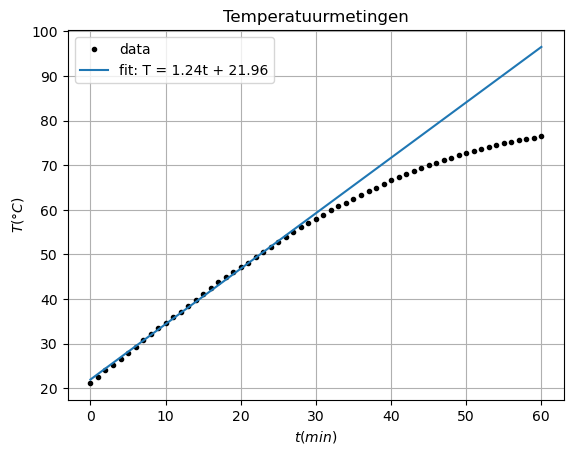

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#inladen van de data
data = np.loadtxt('tempmetingen.csv', delimiter= ';', skiprows=1)
t = data[:, 0] # tijd in minuten
T = data[:,1] # temperatuur in graden celsius

#Eerste deel van de data heeft nauwelijks energie verlies door klein warmteverschil met omgeving we gaan uit van een constante warmtecapaciteit voor water
def model(t, a, b):
    return a*t + b

popt, cov = curve_fit(model, t[:30], T[:30])

print(popt)


#plotten van de data
plt.figure()
plt.plot(t,T, 'k.', label='data')
plt.plot(t, model(t, *popt), label='fit: T = {:.2f}t + {:.2f}'.format(*popt))
plt.xlabel('$t(min)$')
plt.ylabel('$T(°C)$')
plt.title('Temperatuurmetingen')
plt.legend()
plt.grid()
plt.show()



De afwijking van de verwachte trendlijn kan komen door verdamping of mogelijk ook warmteverlies aan de omgeving. Voor het opstellen van de trendlijn is uitgegaabn van een constante warmtecapaciteit en een constante massa.

In [ ]:
def Cp_water(T):

    # Conversie naar Kelvin voor de polynoom
    T_K = T + 273.15
    
    # Coëfficiënten voor Cp in J/mol·K (a + bT + cT² + dT³)
    a = 75.912
    b = 0.14733
    c = -0.0004521
    d = 0.000000628
    
    return a + b*T_K + c*T_K**2 + d*T_K**3

# Schattingen uit metadata
m_beker_g = 820.8
m_start_g = 1292.9
m_eind_g = 1274.9

m_water_start = (m_start_g - m_beker_g) / 1000.0  # kg
m_water_end   = (m_eind_g - m_beker_g) / 1000.0    # kg
m_evap = m_water_end - m_water_start   # kg

# fit-parameter (helling in °C per minuut)
a_per_min = popt[0]
a_K_per_s = a_per_min / 60.0   # °C/s ≈ K/s

# helper: Cp in J/kgK (gebruik jouw Cp per mol en molaire massa)
molar_mass = 0.01801528  # kg/mol
def Cp_per_kg(T_C):
    # Cp_water geeft J/mol/K
    return Cp_water(T_C) / molar_mass

# gemiddelde Cp over het meetbereik door mean theorem
T0 = T[0]
Tf = T[-1]
Ts = np.linspace(T0, Tf, 300)
cp_vals = Cp_per_kg(Ts)
cp_avg = np.trapz(cp_vals, Ts) / (Tf - T0)

# schatting van gemiddeld vermogen (W) als alle energie in startwater gaat
P_est = m_water_start * cp_avg * a_K_per_s

# totale toegevoerde energie over de hele meting (s)
t_total_s = t[-1] * 60.0
E_in = P_est * t_total_s

# energie nodig om water op te warmen (integraal m * ∫Cp dT)
E_heat = m_water_start * np.trapz(cp_vals, Ts)

# latente warmte voor verdampte massa (J/kg)
L_v = 2.257e6
E_vap = abs(m_evap) * L_v

loss = E_in - (E_heat + E_vap)

print(f'Het geschatte verlies is {loss:.2f} J')


Het geschatte verlies is 8359.20 J
